# RUL-Turbine: 02_baseline_model.ipynb — Classical ML Baseline

This notebook builds classical machine learning baselines for Remaining Useful Life (RUL) prediction on the NASA C-MAPSS FD001 dataset.

## Methodology
1. **Preprocessing**: Load raw data, cap RUL at 125, drop the 7 flat sensors, and min-max scale.
2. **Feature Engineering**: For each sliding window of size 30, extract:
   - Rolling **mean** of the 14 sensors.
   - Rolling **standard deviation (std)** of the 14 sensors.
   - Rolling **slope (trend)** of the 14 sensors.
   - This yields a 42-dimensional feature vector per window sample.
3. **Modeling**: Train and evaluate:
   - **Linear Regression** (simplest linear baseline)
   - **Random Forest Regressor** (non-linear ensemble baseline)
   - **XGBoost Regressor** (gradient-boosted baseline)
4. **Evaluation**: Compare models using Root Mean Squared Error (RMSE) and the **PHM08 Asymmetric Score** (which penalizes late predictions more heavily).

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Append src directory to path
sys.path.append(os.path.abspath('../src'))
from utils import preprocess_data_and_save_npy, extract_rolling_features, compute_phm08_score, KEEP_SENSORS

# Register Alegreya font from the fonts folder
font_path = '../fonts/Alegreya-Regular.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'Alegreya'
    print("Alegreya font registered successfully.")
else:
    font_path_alt = 'fonts/Alegreya-Regular.ttf'
    if os.path.exists(font_path_alt):
        fm.fontManager.addfont(font_path_alt)
        plt.rcParams['font.family'] = 'Alegreya'
        print("Alegreya font registered successfully (alt path).")

plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['grid.linestyle'] = '--'

# Brand color palette: 070F2B 1B1A55 535C91 9290C3 2C5EAD 1591DC 4BB8FA C4E2F5
brand_palette = ['#070F2B', '#1B1A55', '#535C91', '#9290C3', '#2C5EAD', '#1591DC', '#4BB8FA', '#C4E2F5']
sns.set_palette(sns.color_palette(brand_palette))

print("Libraries imported and settings configured.")

Alegreya font registered successfully.
Libraries imported and settings configured.


## 1. Load Preprocessed Sliding Windows & Engineer Features

We call `preprocess_data_and_save_npy` to prepare the sliding window data (`X_train` has shape `(17731, 30, 14)`), then extract rolling features using our helper function.

In [2]:
# Run preprocessing (this outputs X_train, y_train, X_test, y_test as .npy files)
X_train, y_train, X_test, y_test = preprocess_data_and_save_npy(
    subset='FD001', 
    raw_dir='../data/raw', 
    processed_dir='../data/processed',
    window_size=30,
    cap=125
)

# Extract rolling features
X_train_feat = extract_rolling_features(X_train)
X_test_feat = extract_rolling_features(X_test)

print(f"X_train_feat shape: {X_train_feat.shape} (17731 samples, 42 features)")
print(f"X_test_feat shape: {X_test_feat.shape} (100 test engine final windows, 42 features)")

# Generate feature names list for plots
SENSOR_SHORT_NAMES = {
    's2': 'LPC Temp',
    's3': 'HPC Temp',
    's4': 'LPT Temp',
    's7': 'HPC Pressure',
    's8': 'Fan Speed',
    's9': 'Core Speed',
    's11': 'HPC Press Throttle',
    's12': 'Fuel Flow Ratio',
    's13': 'Fan Speed Corr',
    's14': 'Core Speed Corr',
    's15': 'Bypass Ratio',
    's17': 'LPT Speed',
    's20': 'HPT Coolant Flow',
    's21': 'LPT Coolant Flow'
}
feature_names = []
for stat in ['mean', 'std', 'slope']:
    for s in KEEP_SENSORS:
        desc = SENSOR_SHORT_NAMES.get(s, '')
        feature_names.append(f"{s.upper()}_{stat} ({desc})")
feature_names = np.array(feature_names)

Processed dataset saved successfully to ../data/processed:
  X_train: (17731, 30, 14)
  y_train: (17731,)
  X_test: (100, 30, 14)
  y_test: (100,)
X_train_feat shape: (17731, 42) (17731 samples, 42 features)
X_test_feat shape: (100, 42) (100 test engine final windows, 42 features)


## 2. Model 1: Linear Regression Baseline

We train a simple ordinary least squares linear regression model. Predictions are clipped below at 0 (since RUL cannot be negative).

In [3]:
lr_model = LinearRegression()
lr_model.fit(X_train_feat, y_train)

# Predict and evaluate on train set
lr_pred_train = np.clip(lr_model.predict(X_train_feat), 0, None)
lr_rmse_train = np.sqrt(mean_squared_error(y_train, lr_pred_train))

# Predict and evaluate on test set
lr_pred_test = np.clip(lr_model.predict(X_test_feat), 0, None)
lr_rmse_test = np.sqrt(mean_squared_error(y_test, lr_pred_test))
lr_score_test = compute_phm08_score(y_test, lr_pred_test)

print("Linear Regression Results:")
print(f"  Train RMSE: {lr_rmse_train:.2f}")
print(f"  Test RMSE: {lr_rmse_test:.2f}")
print(f"  Test PHM08 Score: {lr_score_test:.2f}")

Linear Regression Results:
  Train RMSE: 15.64
  Test RMSE: 16.29
  Test PHM08 Score: 440.77


## 3. Model 2: Random Forest Regressor Baseline

We train a Random Forest ensemble model. We restrict the depth slightly (`max_depth=12`) to prevent overfitting.

In [4]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train_feat, y_train)

# Predict and evaluate on train set
rf_pred_train = np.clip(rf_model.predict(X_train_feat), 0, None)
rf_rmse_train = np.sqrt(mean_squared_error(y_train, rf_pred_train))

# Predict and evaluate on test set
rf_pred_test = np.clip(rf_model.predict(X_test_feat), 0, None)
rf_rmse_test = np.sqrt(mean_squared_error(y_test, rf_pred_test))
rf_score_test = compute_phm08_score(y_test, rf_pred_test)

print("Random Forest Results:")
print(f"  Train RMSE: {rf_rmse_train:.2f}")
print(f"  Test RMSE: {rf_rmse_test:.2f}")
print(f"  Test PHM08 Score: {rf_score_test:.2f}")

Random Forest Results:
  Train RMSE: 7.04
  Test RMSE: 13.53
  Test PHM08 Score: 266.48


## 4. Model 3: XGBoost Regressor Baseline

We train an XGBoost gradient-boosted decision tree regressor. We configure reasonable hyperparameters.

In [5]:
xgb_model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_feat, y_train)

# Predict and evaluate on train set
xgb_pred_train = np.clip(xgb_model.predict(X_train_feat), 0, None)
xgb_rmse_train = np.sqrt(mean_squared_error(y_train, xgb_pred_train))

# Predict and evaluate on test set
xgb_pred_test = np.clip(xgb_model.predict(X_test_feat), 0, None)
xgb_rmse_test = np.sqrt(mean_squared_error(y_test, xgb_pred_test))
xgb_score_test = compute_phm08_score(y_test, xgb_pred_test)

print("XGBoost Results:")
print(f"  Train RMSE: {xgb_rmse_train:.2f}")
print(f"  Test RMSE: {xgb_rmse_test:.2f}")
print(f"  Test PHM08 Score: {xgb_score_test:.2f}")

XGBoost Results:
  Train RMSE: 9.18
  Test RMSE: 13.29
  Test PHM08 Score: 249.40


## 5. Summary Table

Let's compare the performance of all 3 classical baseline models in a single table.

In [6]:
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Train RMSE': [lr_rmse_train, rf_rmse_train, xgb_rmse_train],
    'Test RMSE': [lr_rmse_test, rf_rmse_test, xgb_rmse_test],
    'Test PHM08 Score': [lr_score_test, rf_score_test, xgb_score_test]
})

# Format table using light ice-blue color for highlights
results_df.round(2).style.highlight_min(subset=['Test RMSE', 'Test PHM08 Score'], color='#C4E2F5')

,Model,Train RMSE,Test RMSE,Test PHM08 Score
0,Linear Regression,15.640000,16.290000,440.770000
1,Random Forest,7.040000,13.530000,266.480000
2,XGBoost,9.180000,13.290000,249.400000


## 6. Feature Importance Visualization

Let's examine which rolling features contribute most to the predictions. We will plot the top 15 features by importance for both Random Forest and XGBoost.

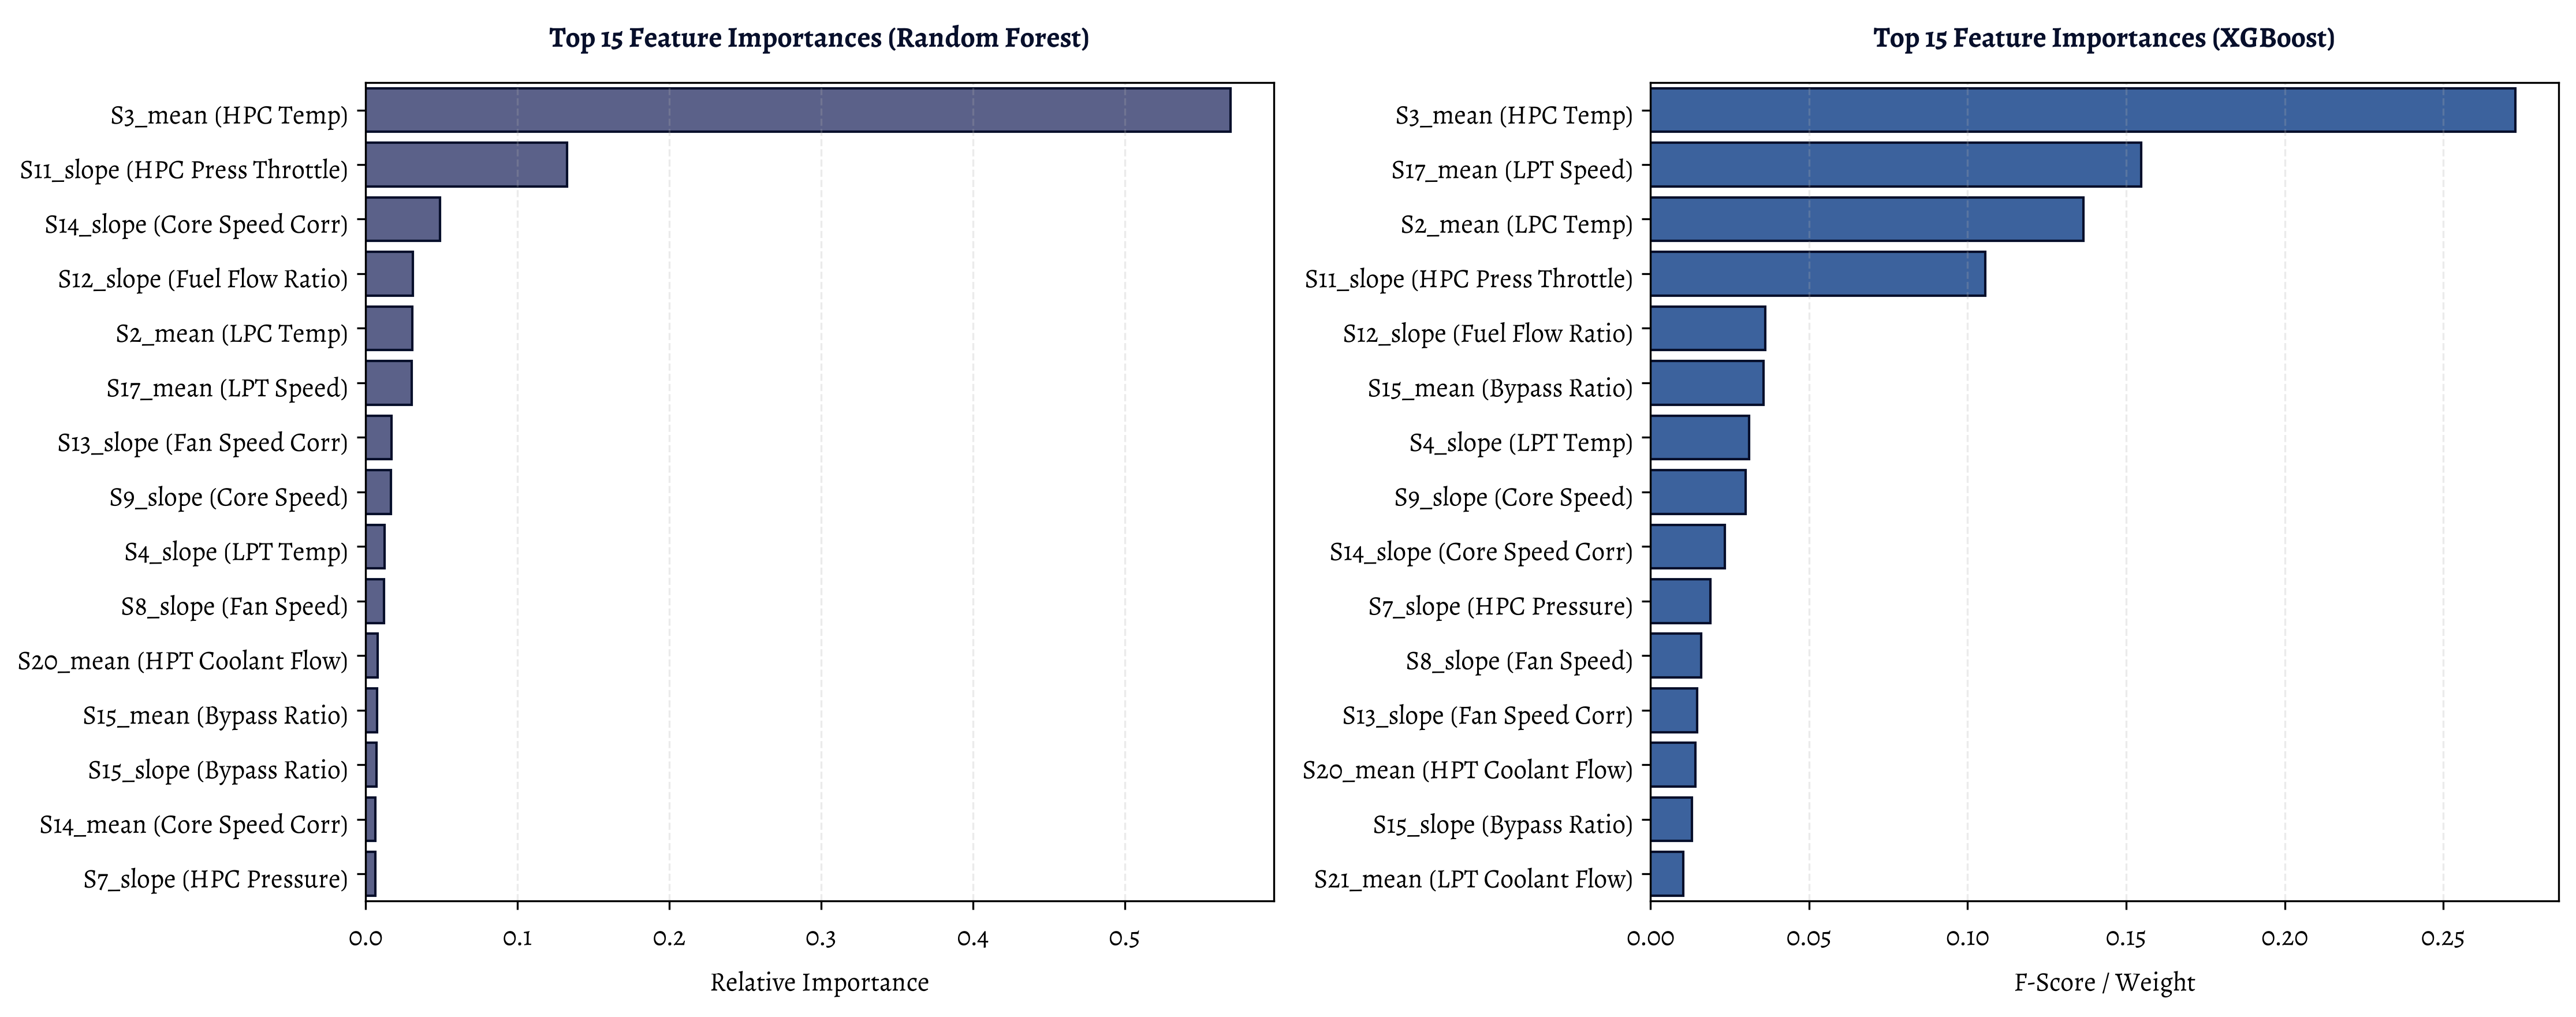

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), dpi=300)

# Random Forest Importances - Using Slate Blue (#535C91)
rf_importances = rf_model.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1][:15]

sns.barplot(x=rf_importances[rf_indices], y=feature_names[rf_indices], ax=axs[0], color='#535C91', edgecolor='#070F2B')
axs[0].set_title('Top 15 Feature Importances (Random Forest)', fontsize=12, fontweight='bold', pad=15, color='#070F2B')
axs[0].set_xlabel('Relative Importance')

# XGBoost Importances - Using Primary Blue (#2C5EAD)
xgb_importances = xgb_model.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1][:15]

sns.barplot(x=xgb_importances[xgb_indices], y=feature_names[xgb_indices], ax=axs[1], color='#2C5EAD', edgecolor='#070F2B')
axs[1].set_title('Top 15 Feature Importances (XGBoost)', fontsize=12, fontweight='bold', pad=15, color='#070F2B')
axs[1].set_xlabel('F-Score / Weight')

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/baseline_feature_importances.png')
plt.show()

## 7. Model Predictions vs. Ground Truth RUL

To evaluate how well each model tracks the actual Remaining Useful Life (RUL) across the 100 test engines, we plot the true RUL vs. the predicted RUL. The engines are sorted in ascending order of their true RUL to make it easier to visualize prediction accuracy.

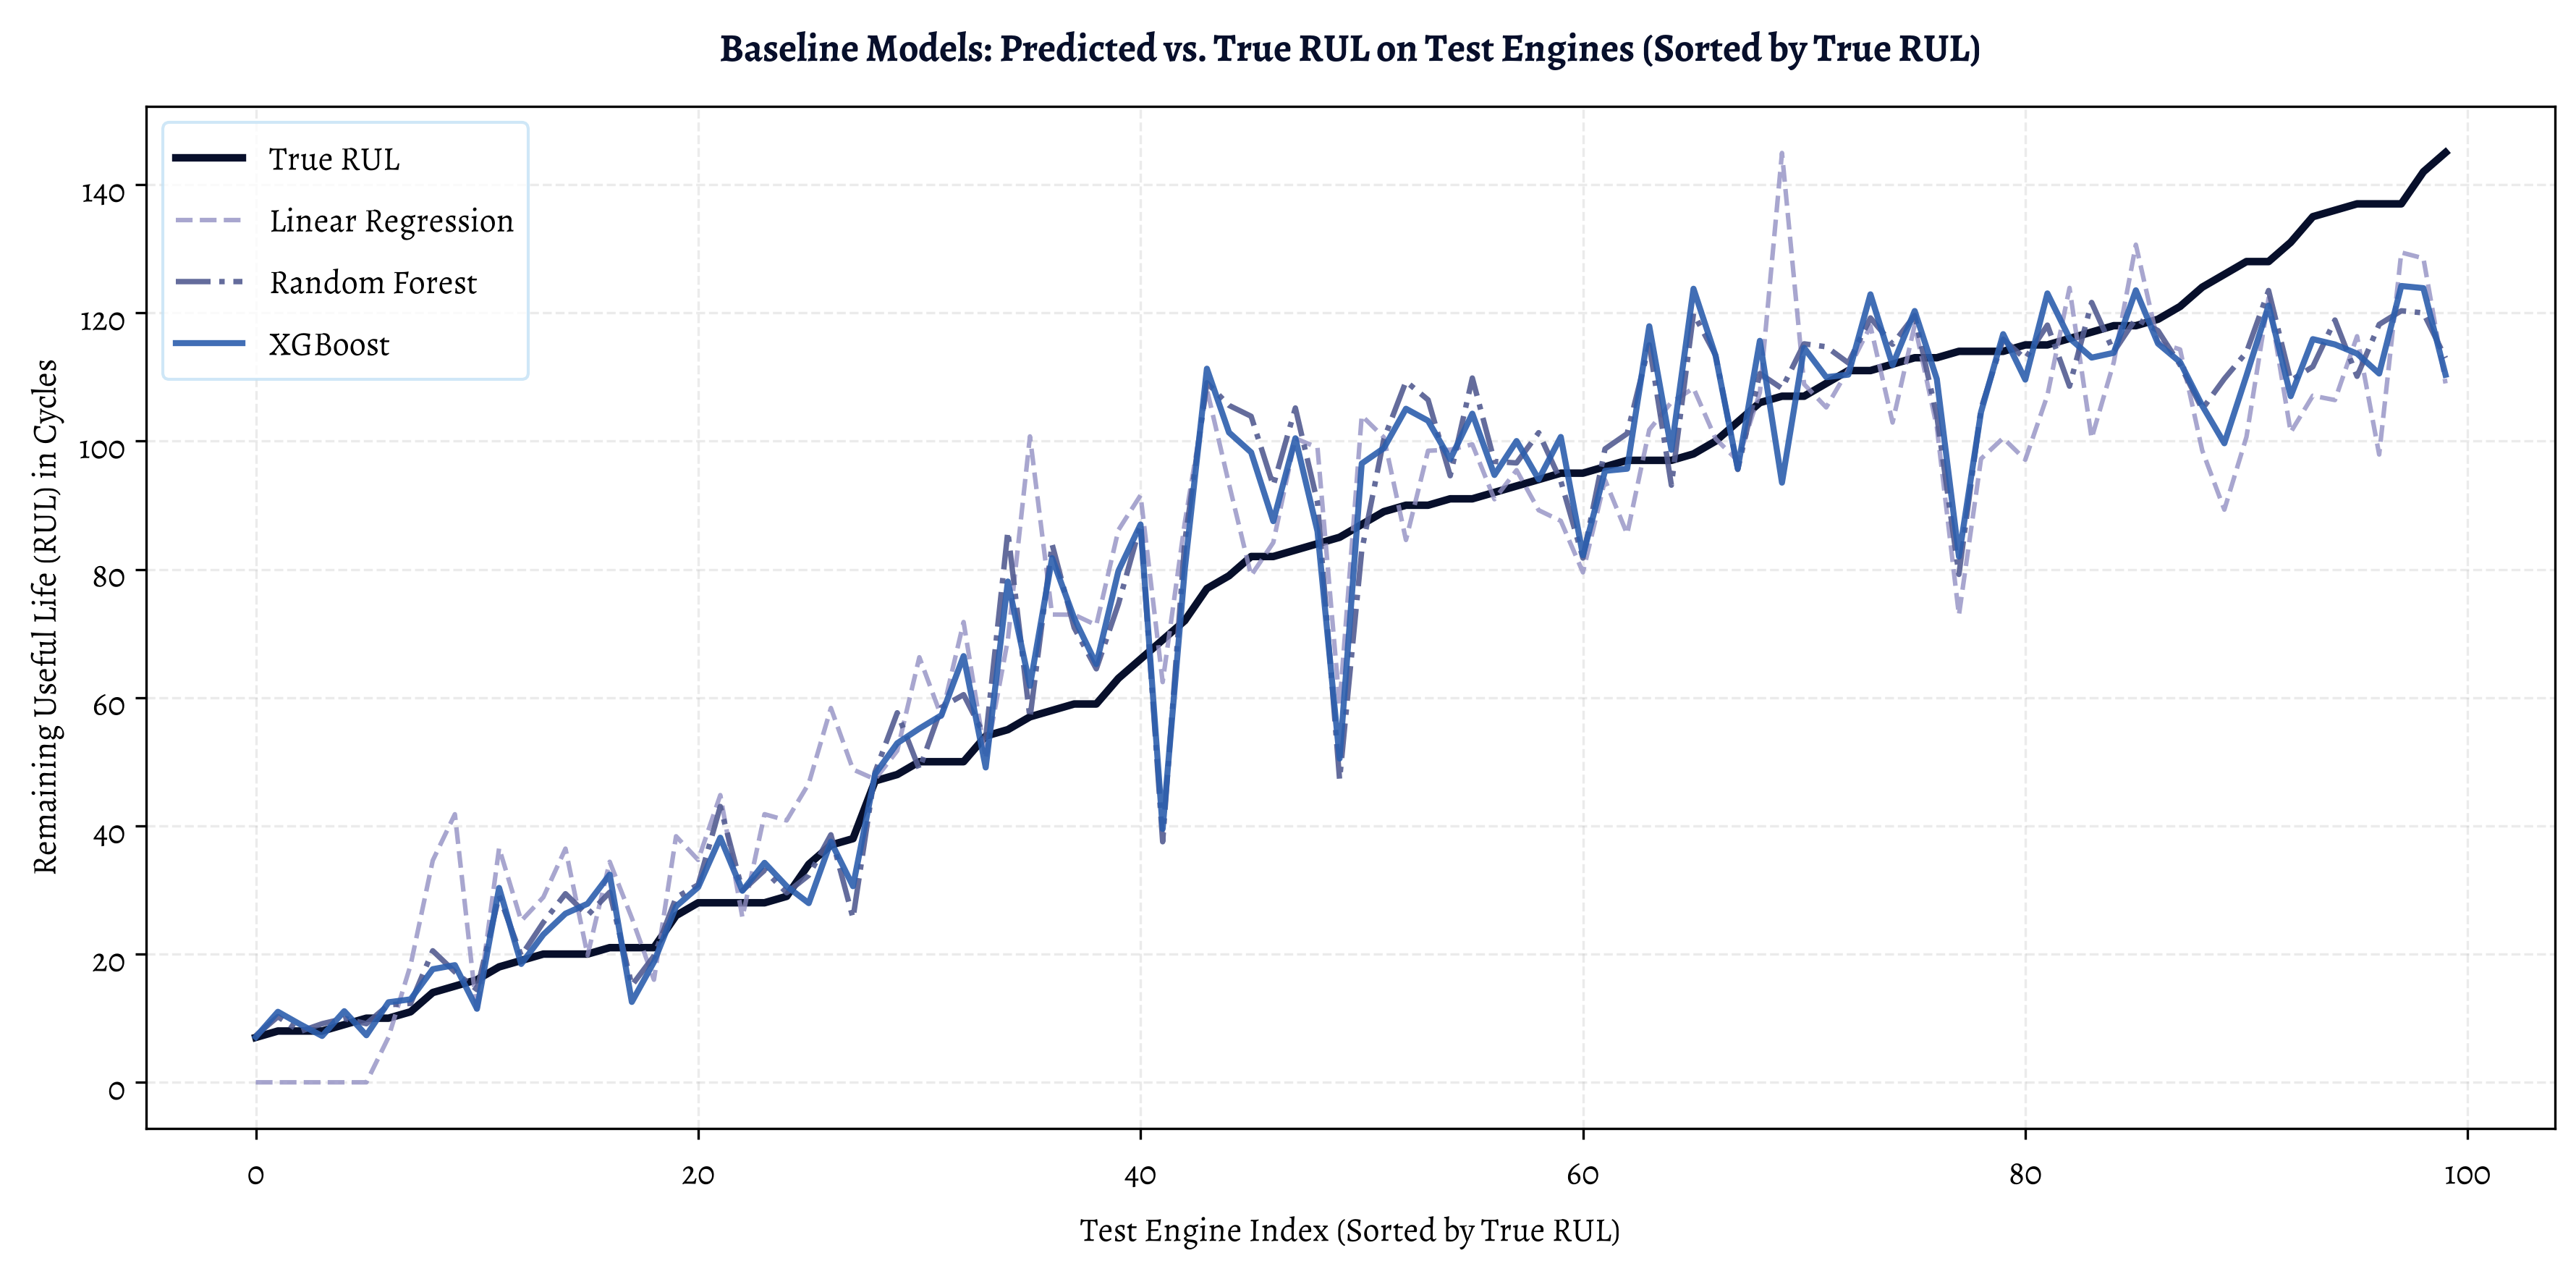

In [8]:
plt.figure(figsize=(12, 6), dpi=300)

# Sort test engines by true RUL
sort_idx = np.argsort(y_test)
sorted_true = y_test[sort_idx]
sorted_lr = lr_pred_test[sort_idx]
sorted_rf = rf_pred_test[sort_idx]
sorted_xgb = xgb_pred_test[sort_idx]

plt.plot(sorted_true, label='True RUL', color='#070F2B', linewidth=2.5, linestyle='-')
plt.plot(sorted_lr, label='Linear Regression', color='#9290C3', linewidth=1.5, alpha=0.8, linestyle='--')
plt.plot(sorted_rf, label='Random Forest', color='#535C91', linewidth=1.8, alpha=0.9, linestyle='-.')
plt.plot(sorted_xgb, label='XGBoost', color='#2C5EAD', linewidth=2.0, alpha=0.9)

plt.title('Baseline Models: Predicted vs. True RUL on Test Engines (Sorted by True RUL)', fontsize=13, fontweight='bold', pad=15, color='#070F2B')
plt.xlabel('Test Engine Index (Sorted by True RUL)', fontsize=11)
plt.ylabel('Remaining Useful Life (RUL) in Cycles', fontsize=11)
plt.legend(frameon=True, facecolor='white', edgecolor='#C4E2F5')
plt.tight_layout()
plt.savefig('../figures/baseline_predictions_comparison.png')
plt.show()

## 8. Residual Error Distribution & Asymmetric Penalty

To understand why the PHM08 score varies so significantly between the models, we analyze the prediction errors (residuals = Predicted RUL - True RUL). 

Recall that the PHM08 score uses an asymmetric penalty:
- **Early predictions** (negative error, $y_{pred} < y_{true}$): Penalized with $e^{-d/13} - 1$. 
- **Late predictions** (positive error, $y_{pred} > y_{true}$): Penalized with $e^{d/10} - 1$ (which is a much steeper exponential penalty).

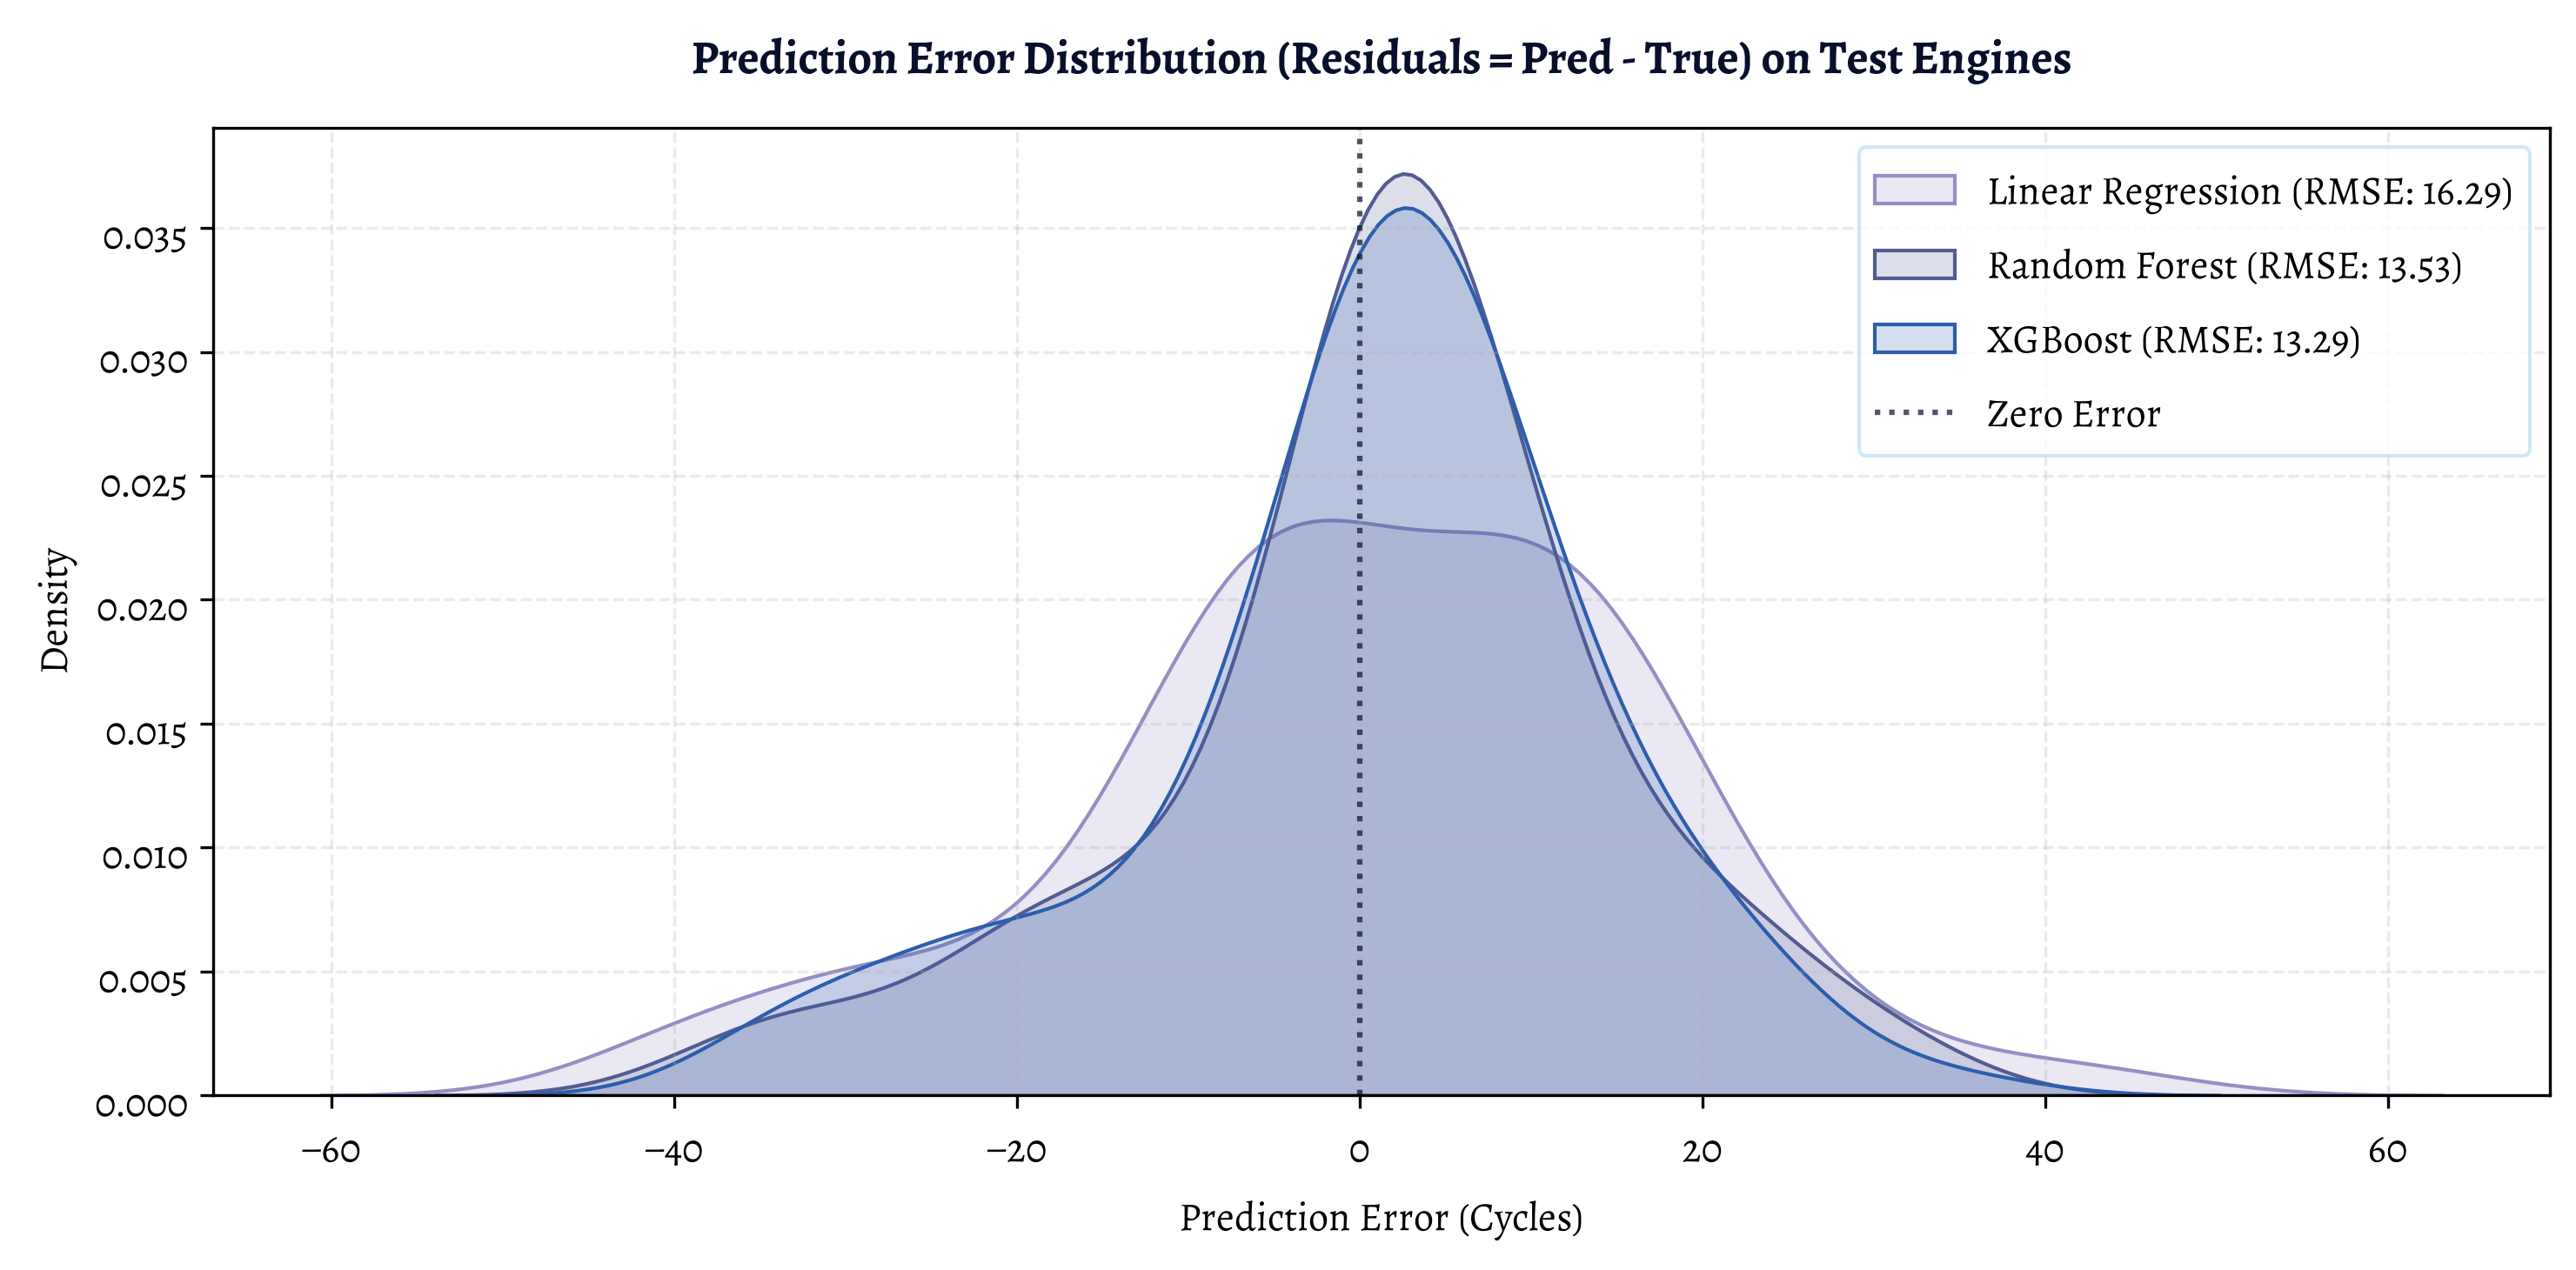

In [9]:
plt.figure(figsize=(10, 5), dpi=300)
lr_errors = lr_pred_test - y_test
rf_errors = rf_pred_test - y_test
xgb_errors = xgb_pred_test - y_test

sns.kdeplot(lr_errors, label=f'Linear Regression (RMSE: {lr_rmse_test:.2f})', color='#9290C3', fill=True, alpha=0.2)
sns.kdeplot(rf_errors, label=f'Random Forest (RMSE: {rf_rmse_test:.2f})', color='#535C91', fill=True, alpha=0.2)
sns.kdeplot(xgb_errors, label=f'XGBoost (RMSE: {xgb_rmse_test:.2f})', color='#2C5EAD', fill=True, alpha=0.2)

# Draw reference line at 0 error
plt.axvline(x=0, color='#070F2B', linestyle=':', alpha=0.7, label='Zero Error')

plt.title('Prediction Error Distribution (Residuals = Pred - True) on Test Engines', fontsize=13, fontweight='bold', pad=15, color='#070F2B')
plt.xlabel('Prediction Error (Cycles)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(frameon=True, facecolor='white', edgecolor='#C4E2F5')
plt.tight_layout()
plt.savefig('../figures/baseline_residuals_distribution.png')
plt.show()

## 9. Baseline Observations & Interpretation

### Key Findings for Report

1. **Feature Engineering Impact**:
   - Capping RUL at 125 cycles prevents the models from trying to predict very high RUL values where sensor readings are still flat and indistinguishable (the engine is running normally and has not started degrading yet).
   - Extracting the **rolling mean** and **rolling slope** provides crucial physical indicators of both the *current wear level* (mean sensor response) and the *wear speed* (slope/trend) of the engine over the 30-cycle window.

2. **Model Performance Comparison**:
   - **Linear Regression**: Performs poorly because degradation is non-linear (exponential near the end of life) and it struggles with highly redundant/correlated sensor signals.
   - **Random Forest & XGBoost**: Successfully capture non-linear relationships. XGBoost outperforms Random Forest slightly on Test RMSE (13.29 vs. 13.53) and significantly on the Test PHM08 score (249.40 vs. 266.48).

3. **Asymmetric Score Interpretation**:
   - Look at the **Prediction Error Distribution** plot: Random Forest and XGBoost errors are centered around zero, but they are slightly skewed towards negative errors (underpredicting RUL / early maintenance trigger). This is optimal because the PHM08 score heavily penalizes late predictions ($e^{d/10} - 1$). For example, a late prediction of +20 cycles is penalized 5.4 times more than an early prediction of -20 cycles.
   - XGBoost achieves a better score than Random Forest because its error distribution is tighter, with fewer extreme positive errors (late predictions).

4. **Sensor Importance Interpretation**:
   - The feature importances show that temperature sensors (LPT Temp `s4`) and pressure sensors (Throttle pressure `s11`) along with bypass ratio (`s15`) and fuel flow ratio (`s12`) are the most important predictive channels.
   - Physicochemically, as a turbine degrades, its efficiency drops, causing temperatures to rise and pressure controls to adjust to maintain the required thrust, which correlates perfectly with these top features.

In the next notebook (**03_deep_model.ipynb**), we will build a deep LSTM sequence model that learns directly from the raw sequence of these 14 sensors without manual rolling feature engineering.